# Probabilidad de completar el album con dos cajas e intercambio K=4

Parametros reales del album:

- Estampas del album: `N = 980`.
- Estampas por sobre: `S = 7`.
- Sobres por caja: `104`.
- Dos cajas: `M = 208` sobres.
- Intercambio: cada `K = 4` repetidas se canjean por 1 estampa faltante.
- Simulaciones: `R = 250000`.
- Semilla: `2026`.
- Precio por caja: `Q975.00`.


In [7]:
import numpy as np
import matplotlib.pyplot as plt

SEMILLA = 2026
N = 980
S = 7
R = 250_000
K = 4

SOBRES_POR_CAJA = 104
CAJAS = 2
M = CAJAS * SOBRES_POR_CAJA

PRECIO_CAJA = 975.00
costo_total = CAJAS * PRECIO_CAJA


## Funcion de simulacion

Para reducir la carga, la simulacion guarda cuantas estampas distintas tiene el album. Si hay `c` estampas coleccionadas, el numero de estampas nuevas en el siguiente sobre sigue una distribucion hipergeometrica. Despues de cada sobre se aplican todos los canjes posibles de repetidas por estampas faltantes.

Cuando `k=None`, el escenario es sin intercambio. Cuando `k=4`, cada 4 repetidas acumuladas producen una estampa faltante.


In [8]:
def simular_probabilidad_completar(n, s, r, m, k=None, semilla=2026):
    rng = np.random.default_rng(semilla)
    coleccionadas = np.zeros(r, dtype=np.int16)
    repetidas = np.zeros(r, dtype=np.int16)

    for _ in range(m):
        activos = coleccionadas < n
        idx = np.flatnonzero(activos)
        if idx.size == 0:
            break

        nuevas = rng.hypergeometric(n - coleccionadas[idx], coleccionadas[idx], s)
        duplicadas = s - nuevas
        coleccionadas[idx] += nuevas.astype(np.int16)

        if k is not None:
            repetidas[idx] += duplicadas.astype(np.int16)
            canjes = np.minimum(repetidas[idx] // k, n - coleccionadas[idx])
            coleccionadas[idx] += canjes.astype(np.int16)
            repetidas[idx] -= (canjes * k).astype(np.int16)

    completado = coleccionadas >= n
    return {
        "probabilidad": completado.mean(),
        "exitos": int(completado.sum()),
        "coleccionadas": coleccionadas,
        "faltantes": n - coleccionadas,
    }


In [9]:
resultado = simular_probabilidad_completar(N, S, R, M, k=K, semilla=SEMILLA)

print(f"Sobres comprados: {M}")
print(f"Costo total: Q{costo_total:,.2f}")
print(f"Exitos: {resultado['exitos']} de {R}")
print(f"Probabilidad estimada de completar: {resultado['probabilidad']:.4f}")
print(f"Faltantes promedio: {resultado['faltantes'].mean():.4f}")
print(f"Faltantes mediana: {np.median(resultado['faltantes']):.0f}")
print(f"Minimo de estampas coleccionadas: {resultado['coleccionadas'].min()}")
print(f"Maximo de estampas coleccionadas: {resultado['coleccionadas'].max()}")


Sobres comprados: 208
Costo total: Q1,950.00
Exitos: 0 de 250000
Probabilidad estimada de completar: 0.0000
Faltantes promedio: 100.9773
Faltantes mediana: 101
Minimo de estampas coleccionadas: 846
Maximo de estampas coleccionadas: 912


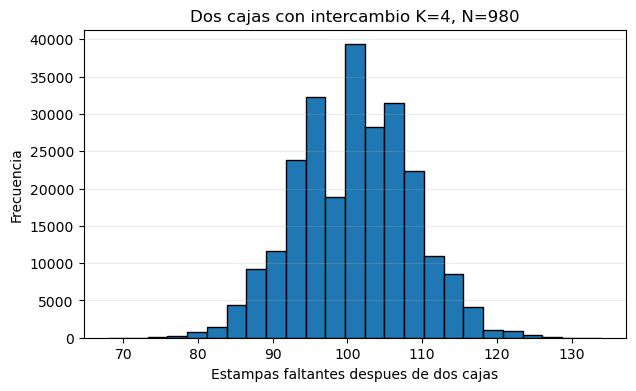

In [10]:
plt.figure(figsize=(7, 4))
plt.hist(resultado["faltantes"], bins=25, edgecolor="black")
plt.xlabel("Estampas faltantes despues de dos cajas")
plt.ylabel("Frecuencia")
plt.title("Dos cajas con intercambio K=4, N=980")
plt.grid(axis="y", alpha=0.25)
plt.show()


## Respuesta

Con dos cajas (`208` sobres) e intercambio `K=4`, la probabilidad estimada de completar el album fue `0.0000`, es decir, `0` exitos en `250000` simulaciones.

En promedio faltaron `100.9773` estampas; la mediana de faltantes fue `101`.

El costo de dos cajas es `2 x Q975.00 = Q1950.00`.

Nota: una probabilidad simulada de `0.0000` significa que no se observaron exitos en estas `250000` simulaciones; no es una prueba matematica de imposibilidad absoluta.


## Revisión de consistencia

El resultado `0.0000` con dos cajas no parece ser un error del código. Una forma rápida de revisarlo es imaginar que se abren todos los sobres primero y se hacen los canjes al final. Si `T = M × S` es el total de estampas compradas y `U` es el número de estampas distintas que aparecerían sin canjes, entonces el máximo aproximado alcanzable con canjes `K=4` es:

`U + floor((T - U)/4)`.

Para completar se necesitaría `U + (T-U)/4 >= 980`, es decir:

`U >= ceil((4×980 - T)/3)`.

Con dos cajas, `T = 208×7 = 1456`, así que se necesitarían al menos `822` estampas distintas naturales antes de canjear. En una revisión con `250000` pruebas, el número de distintas sin canje estuvo entre `719` y `808`, nunca llegó a `822`. Por eso el resultado de `0` éxitos es coherente; con `K=4`, dos cajas se quedan cortas por unas `101` estampas en promedio.
